<a href="https://colab.research.google.com/github/Rehman-Cg7/AIML/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Titaanic Dataset.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Titaanic Dataset.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Sex                      887 non-null    object 
 3   Age                      887 non-null    float64
 4   Siblings/Spouses Aboard  887 non-null    int64  
 5   Parents/Children Aboard  887 non-null    int64  
 6   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.6+ KB


In [ ]:
df.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Siblings/Spouses Aboard,0
Parents/Children Aboard,0
Fare,0


In [ ]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Fare,float64


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

titanic.head()
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handling Missing Values

- Age: Median se fill kiya kyunke age mein outliers hain, aur mean unse affect ho jata — median zyada stable hai.
- Cabin: Column drop kar diya kyunke isme 70%+ values missing thi — itna missing data fill karna galat estimate dega.
- Embarked: Sirf 2 missing values thi, is liye mode (sabse common value) se fill kiya.

In [3]:
# Age ko median se fill karo
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

# Embarked ko mode se fill karo
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

# Cabin column drop karo (bohot missing values hain)
titanic.drop(columns=['Cabin'], inplace=True)

# Dobara check karo
titanic.isnull().sum()

/tmp/ipykernel_1246/1073401892.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
/tmp/ipykernel_1246/1073401892.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#4 Visualizations

###1. Histogram — Age distribution

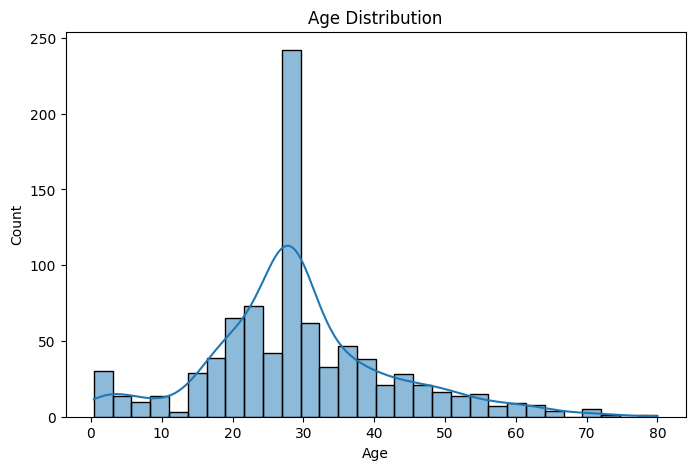

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(titanic['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

###2. Boxplot — Age by Survival

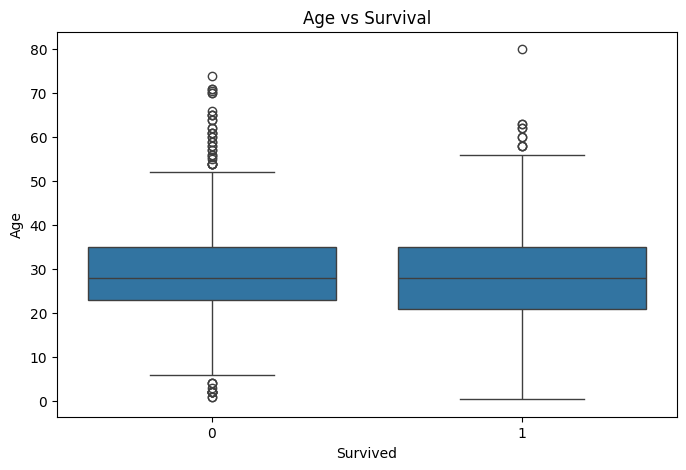

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=titanic)
plt.title('Age vs Survival')
plt.show()

###3. Bar chart — Survival by Gender

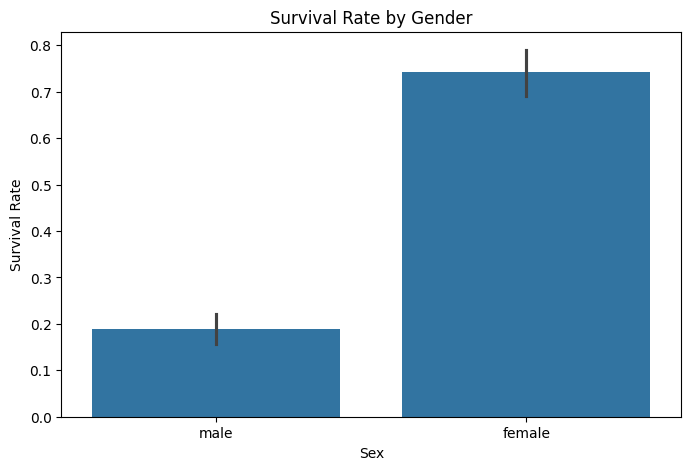

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=titanic)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

###4. Correlation Heatmap

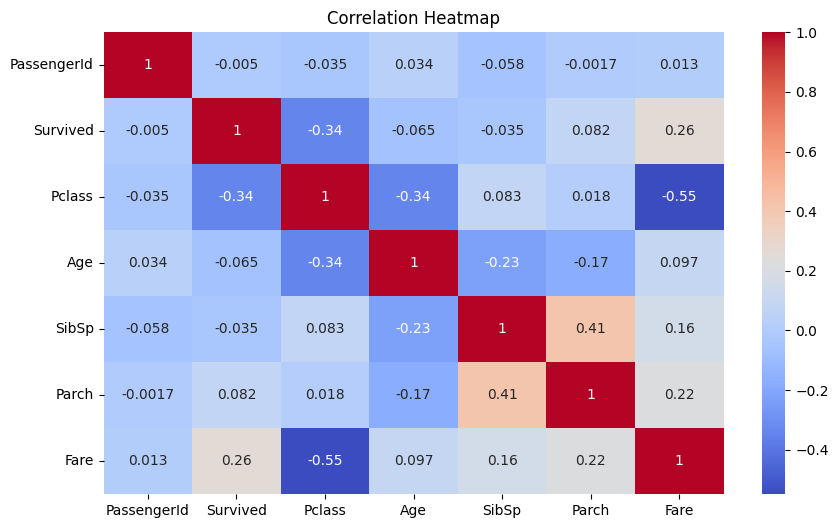

In [7]:
plt.figure(figsize=(10,6))
numeric_cols = titanic.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Which feature affects survival most?

Sex (gender) survival ko sabse zyada affect karta hai. Bar chart mein clearly dikha
ke females ki survival rate males se kaafi zyada thi — "women and children first"
policy ke wajah se. Heatmap mein bhi Pclass (ticket class) ka strong correlation
survival ke saath dikha — higher class passengers ki survival chance zyada thi,
shayad unko lifeboats tak pehle access mila.